# Load modules

In [1]:
import sys
import os
from pathlib import Path

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from config.config_main import config as path_config

root = path_config.root

from anonymization.diffusion import DiffusionModel
from fr_system.bisenet import BiSeNet
from fr_system.mtcnn import MTCNN
from data.dataset import load_dataset
from data.transforms import get_base_transforms
from anonymization.flip_anonymizer import FlipAnonymizer
from utils.image_utils import save_image, tensor_to_pil
import torch
from torch.utils.data import DataLoader
import tqdm
from torchvision.utils import make_grid
from torchvision import transforms
import numpy as np
from PIL import Image
import torch.nn as nn
import ot 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
cos = nn.CosineSimilarity(dim=1, eps=1e-6)

import torch.nn.functional as F

def compute_tar_at_far(
    emb1: torch.Tensor,
    emb2: torch.Tensor,
    labels1,
    labels2,
    target_far: float = 0.001,
):
    emb1 = F.normalize(emb1, dim=1)
    emb2 = F.normalize(emb2, dim=1)

    sim = emb1 @ emb2.T


    genuine_mask = labels1[:, None] == labels2[None, :]
    impostor_mask = ~genuine_mask

    genuine_scores = sim[genuine_mask]
    impostor_scores = sim[impostor_mask]
    threshold = torch.quantile(impostor_scores, 1 - target_far)
    tar = (genuine_scores >= threshold).float().mean().item()

    return tar, threshold.item()

def compute_tar_at_threshold(
    emb1: torch.Tensor,
    emb2: torch.Tensor,
    labels1,
    labels2,
    threshold,
):
    emb1 = F.normalize(emb1, dim=1)
    emb2 = F.normalize(emb2, dim=1)

    sim = emb1 @ emb2.T


    genuine_mask = labels1[:, None] == labels2[None, :]

    genuine_scores = sim[genuine_mask]
    tar = (genuine_scores >= threshold).float().mean().item()

    return tar

c:\Users\Pol\miniconda3\envs\xor\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'ot'

In [ ]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 3

# Load results

In [ ]:
from easydict import EasyDict as edict
import os
 

config = edict()
config.DATASET = "LFW" # "LFW" "CelebA_HQ", "FFHQ"
config.batch_size = 5

config.diffusion_name = "ffhq" # controlnet_landmarks_5, controlnet_landmarks_26, controlnet_segmentation_masks, ffhq, multi_controlnet
config.guidance = False # default = False
config.guidance_type = "segmentation" # "landmarks", "segmentation"
config.controlnet = False # default = True
config.ddim_inversion = True # default = False
config.evaluation = "standard" # "standard", "diversity"

if config.guidance == True:
    config.guidance_scale = 5
else : 
    config.guidance_scale = None

config.fr_models = ["facenet_vggface2", "facenet_casia"]

config.mask = "anonymized_face" # "original_face", "anonymized_face"
config.seeds = "identity"

if config.ddim_inversion:
    prefix = "ddim_inversion"
else :
    prefix = "controlnet_inversion"

if config.guidance == True:
    config.save_path_suffix = f"conditionned_{config.guidance_type}{config.guidance_scale}_mask_{config.mask}_{prefix}"
    # config.save_path_suffix = f"test"
elif config.controlnet == True:
    config.save_path_suffix = f"{config.diffusion_name}_mask_{config.mask}_{prefix}"
else :
    config.save_path_suffix = f"unconditionned_mask_{config.mask}_{prefix}"

if config.evaluation == "diversity":
    config.save_path_suffix = os.path.join("diversity_evaluation", config.save_path_suffix)
    config.n_size = 1000
elif config.evaluation == "standard":
    config.n_size = 2500

In [4]:
mae = torch.empty(0)
ssim = torch.empty(0)
psnr = torch.empty(0)
fid = []
fid_recon = []
t_clean = {model : torch.empty(0) for model in ["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]}
t_ano = {model : torch.empty(0) for model in ["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]}
t_reco = {model : torch.empty(0) for model in ["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]}
utility_maintenance_metrics = {"anonymization": {"face_detection": torch.empty(0),
                                                  "bbox_distance": torch.empty(0),
                                                  "landmark_distance": torch.empty(0),
                                                  'iou_mask': torch.empty(0),
                                                  'dice_mask' : torch.empty(0)},
                                "reconstruction": {"face_detection": torch.empty(0),
                                                  "bbox_distance": torch.empty(0),
                                                  "landmark_distance": torch.empty(0)}}
if config.DATASET == "CelebA_HQ":
    irange = 12
elif config.DATASET == "LFW":
    irange = 1
for i in range(irange):
    r = torch.load(os.path.join(root, "results", config.DATASET, config.save_path_suffix, f"results_part_{i}.pt"))
    mae = torch.cat([mae, r["mae"]])
    ssim = torch.cat([ssim, r["ssim"]])
    psnr = torch.cat([psnr, r["psnr"]])
    fid.append(r["fid"])
    fid_recon.append(r["fid_recon"])
    for key in utility_maintenance_metrics.keys():
        for sub_key in utility_maintenance_metrics[key].keys():
            if sub_key == "face_detection":
                r["utility_maintenance_metrics"][key][sub_key] = r["utility_maintenance_metrics"][key][sub_key][:,0]
            utility_maintenance_metrics[key][sub_key] = torch.cat([utility_maintenance_metrics[key][sub_key], r["utility_maintenance_metrics"][key][sub_key]])
    
    for model in ["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]:
        t_clean[model] = torch.cat([t_clean[model], r[model]["clean"]])
        t_ano[model] = torch.cat([t_ano[model], r[model]["anonymized"]])
        t_reco[model] = torch.cat([t_reco[model], r[model]["reconstructed"]])



In [28]:
print(mae.mean(), ssim.mean(), psnr.mean())

tensor(0.1074) tensor(0.8569) tensor(20.6950) 55.158470153808594 33.22488784790039


In [19]:
for key in utility_maintenance_metrics.keys():
    for sub_key in utility_maintenance_metrics[key].keys():
        print(key, sub_key, utility_maintenance_metrics[key][sub_key].mean())

anonymization face_detection tensor(1.)
anonymization bbox_distance tensor(6.1611, dtype=torch.float64)
anonymization landmark_distance tensor(40.8373, dtype=torch.float64)
anonymization iou_mask tensor(0.9198)
anonymization dice_mask tensor(0.9557)
reconstruction face_detection tensor(0.9994)
reconstruction bbox_distance tensor(5.0912, dtype=torch.float64)
reconstruction landmark_distance tensor(18.5170, dtype=torch.float64)


In [14]:

for model in t_clean.keys():
    cosine = cos(t_ano[model], t_clean[model])
    print(model, "ano",  cosine.mean(), cosine.std(), cosine.max(), cosine.min())
    cosine = cos(t_reco[model], t_clean[model])
    print(model, "rec",  cosine.mean(), cosine.std())

facenet_vggface2_templates ano tensor(0.0781) tensor(0.1636) tensor(0.7518) tensor(-0.5095)
facenet_vggface2_templates rec tensor(0.7447) tensor(0.1946)
facenet_casia_templates ano tensor(0.0925) tensor(0.1403) tensor(0.6789) tensor(-0.4066)
facenet_casia_templates rec tensor(0.7427) tensor(0.1818)
arcface_r50_templates ano tensor(0.0293) tensor(0.0773) tensor(0.3982) tensor(-0.3381)
arcface_r50_templates rec tensor(0.6921) tensor(0.2011)
adaface_vit_templates ano tensor(0.0492) tensor(0.0779) tensor(0.4992) tensor(-0.2270)
adaface_vit_templates rec tensor(0.7065) tensor(0.1802)


# LFW true acceptance rate

In [20]:
clean = torch.load(os.path.join(root, "results", "LFW", "clean_first_image.pt"))
for model in clean.keys():
    clean[model] = clean[model
    ]["clean"].cuda()

names = np.load(os.path.join(root, "results", "LFW", "names.npy"), allow_pickle=True)
names = names.item()

In [21]:
names

{'names1': array(['Aaron_Peirsol', 'Aaron_Peirsol', 'Aaron_Sorkin', ...,
        'Yevgeny_Kafelnikov', 'Yoriko_Kawaguchi', 'Zoran_Djindjic'],
       shape=(1600,), dtype='<U31'),
 'names2': array(['Aaron_Peirsol', 'Aaron_Peirsol', 'Aaron_Sorkin', ...,
        'Yevgeny_Kafelnikov', 'Yoriko_Kawaguchi', 'Zoran_Djindjic'],
       shape=(1600,), dtype='<U31')}

In [22]:
thresholds = {model:None for model in clean.keys()}
tar_clean = {model:None for model in clean.keys()}
for model in clean.keys():
    tar_clean[model], thresholds[model] = compute_tar_at_far(t_clean[model + "_templates"].cuda(), clean[model],
    labels1 = names["names1"],  labels2 = names["names2"], target_far=0.001)
print(tar_clean, thresholds)

{'arcface_r50': 0.9905725717544556, 'facenet_vggface2': 0.95146644115448, 'facenet_casia': 0.9095669984817505, 'adaface_vit': 0.9961591958999634} {'arcface_r50': 0.24617506563663483, 'facenet_vggface2': 0.5562378764152527, 'facenet_casia': 0.5122511386871338, 'adaface_vit': 0.24919302761554718}


In [29]:
tar_ano = {model:None for model in clean.keys()}
for model in clean.keys():
    tar_ano[model] = compute_tar_at_threshold(t_ano[model + "_templates"].cuda(), clean[model],
    labels1 = names["names1"],  labels2 = names["names2"], threshold = thresholds[model])
print(tar_ano)

{'arcface_r50': 0.005586592014878988, 'facenet_vggface2': 0.006284915842115879, 'facenet_casia': 0.002793296007439494, 'adaface_vit': 0.0048882681876420975}


In [30]:
tar_reco = {model:None for model in clean.keys()}
for model in clean.keys():
    tar_reco[model] = compute_tar_at_threshold(t_reco[model + "_templates"].cuda(), clean[model],
    labels1 = names["names1"],  labels2 = names["names2"], threshold = thresholds[model])
print(tar_reco)

{'arcface_r50': 0.7053072452545166, 'facenet_vggface2': 0.4256284832954407, 'facenet_casia': 0.3875698149204254, 'adaface_vit': 0.7021647691726685}


# Extract second image pairs of LFW for face recognition

In [2]:
from fr_system.fr_pipeline import FRPipeline
from data.dataset import load_dataset
from data.transforms import get_base_transforms
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 10
DATASET = "LFW" # or "FFHQ" "LFW"
# Load dataset (synthetic or real)
tfms = get_base_transforms(DATASET)
dataset = load_dataset(DATASET, transform=tfms, split="all", multiple_images=True,
                       data_root=path_config.data_root, dataset_roots=path_config.dataset_roots) # or "LFW"
print(f"Dataset size: {len(dataset)}")
dataset = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# Initialize face recognition pipelines
face_recognizer_models = ["arcface_r50", "facenet_vggface2", "facenet_casia"]
fr_pipelines = {model: FRPipeline(face_detector_name="mtcnn", face_recognizer_name=model, device="cuda", models_dir=path_config.models_root) for model in face_recognizer_models}

# Initialize storage for all models
templates = {model: {'clean': []} for model in face_recognizer_models}


for i, images in enumerate(tqdm.tqdm(dataset)):
    # print(images)
    if DATASET == "LFW":
        images = images[0]  # for lfw following G2Face benchmark we anonymize the second image of positive pairs
    else :
        images = images[0]
    images = images.to(device)

    # Compute face recognition templates
    for model_name, fr_pipeline in fr_pipelines.items():
        # Compute templates for clean, anonymized and reconstructed images
        for img_name, face in zip(["clean"], [images]):
            with torch.no_grad():
                face_features = fr_pipeline(face)
            templates[model_name][img_name].append(face_features.cpu())      

MSI
MSI
MSI
Dataset size: 1600


c:\Users\Pol\miniconda3\envs\xor\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loaded ViT model
compatible keys in state_dict 281 / 281
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt


c:\Users\Pol\miniconda3\envs\xor\lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for net.pos_embed: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Pol\miniconda3\envs\xor\lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for net.patch_embed.proj.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Pol\miniconda3\envs\xor\lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for net.patch_embed.proj.bias: copying from a non-meta parameter in the checkpoint to a meta pa

In [7]:
# Concatenate all templates for each model
final_templates = {}
final_ano_templates = {}
final_recon_templates = {}


for model_name in templates.keys():
    if templates[model_name]:  # Check if we have any templates

        templates[model_name]['clean'] = torch.cat(templates[model_name]['clean'], dim=0)
        print(f"Final template shape for {model_name}: {templates[model_name]['clean'].shape}")


        os.makedirs(f"results/{DATASET}", exist_ok=True)
        torch.save(templates, f"results/{DATASET}/clean_first_image.pt")
        # torch.save({
        #     'templates': final_templates[model_name],
        #     'templates_ano': final_ano_templates[model_name],
        #     'templates_recon': final_recon_templates[model_name],
        #     'keys': torch.cat(all_keys, dim=0)
        # }, f"results/{DATASET}/{config.save_path_suffix}/{DATASET}_{model_name}_{argparse.n}_templates.pt")

print("Results saved!")

Final template shape for arcface_r50: torch.Size([1600, 512])
Final template shape for facenet_vggface2: torch.Size([1600, 512])
Final template shape for facenet_casia: torch.Size([1600, 512])
Final template shape for adaface_vit: torch.Size([1600, 512])
Results saved!


In [35]:
from fr_system.fr_pipeline import FRPipeline
from data.dataset import load_dataset
from data.transforms import get_base_transforms
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 10
DATASET = "LFW" # or "FFHQ" "LFW"
# Load dataset (synthetic or real)
tfms = get_base_transforms(DATASET)
dataset = load_dataset(DATASET, transform=tfms, split="all", multiple_images=True,
                       data_root=path_config.data_root, dataset_roots=path_config.dataset_roots) # or "LFW"
print(f"Dataset size: {len(dataset)}")
dataset = DataLoader(dataset, batch_size=batch_size, shuffle=False)

names1 = []
names2 = []
for i, images in enumerate(tqdm.tqdm(dataset)):
    # print(images)
    img1, img2, name1, name2 = images
    names1.append(list(name1))
    names2.append(list(name2))


r6i3n8
r6i3n8
Dataset size: 1600


100%|██████████| 160/160 [00:42<00:00,  3.76it/s]


In [48]:
names1 = np.asarray(names1).flatten()
names2 = np.asarray(names2).flatten()

In [50]:
names = {'names1' : names1,
        'names2' : names2}
np.save(os.path.join(root, "results", "LFW", "names.npy"), names)

# Diversity plots

In [4]:
methods = ["controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion",
            "G2Face", "iFADIT", "RiDDLE"]
models = ["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]

facef = {method: {model : {"clean": torch.empty(0), "ano" : torch.empty(0), "reco": torch.empty(0)} for model in models} for method in methods}
DATASET = "CelebA_HQ" # "LFW", "CelebA_HQ"

for method in methods:
    if "controlnet" in method:
        results_dir = os.path.join(root, "results", DATASET, "diversity_evaluation", "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion")
    elif "G2Face" in method:
        results_dir = os.path.join(root, "ext_ano", "G2Face", "results", DATASET, "without_mtcnn", "diversity_evaluation")
    elif "iFADIT" in method:
        results_dir = os.path.join(root,"ext_ano", "iFADIT", "results", DATASET, "diversity_evaluation")
    elif "RiDDLE" in method:
        results_dir = os.path.join(root,"ext_ano", "RiDDLE", "results", DATASET, "additional_data", "diversity_evaluation")
        # results_dir = os.path.join(root, "RiDDLE", "results", DATASET, "diversity_evaluation")
    for i in range(10):
        if "controlnet" in method:
            r = torch.load(os.path.join(results_dir, f"results_part_{i}.pt"))
        elif "G2Face" in method:
            r = torch.load(os.path.join(results_dir, f"results_{i}.pt"))
        elif "iFADIT" in method:
            r = torch.load(os.path.join(results_dir, f"results_{i}.pt"))
        elif "RiDDLE" in method:
            r = torch.load(os.path.join(results_dir, f"results_{i}.pt"))
        for model in models:
            for facef_type, new_facef_type in zip(["clean", "anonymized", "reconstructed"], ["clean", "ano", "reco"]):
                facef[method][model][new_facef_type] = torch.cat([facef[method][model][new_facef_type], r[model][facef_type]])


## cosine x_ano(ki) and x_ano(kj) i diff j

arcface_r50_templates tensor(0.0963, device='cuda:0') tensor(0.0891, device='cuda:0')
adaface_vit_templates tensor(0.1276, device='cuda:0') tensor(0.0881, device='cuda:0')


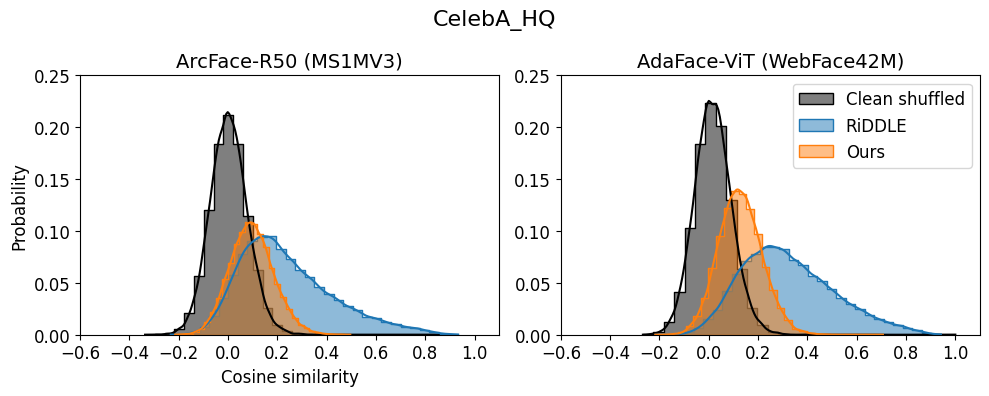

In [12]:
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
map_models_name = {"facenet_vggface2_templates" : "FaceNet (VGGFace2)", "facenet_casia_templates" : "FaceNet (Casia)",
 "arcface_r50_templates": "ArcFace-R50 (MS1MV3)", "adaface_vit_templates": "AdaFace-ViT (WebFace42M)"}
methods = ["RiDDLE", "G2Face",  "iFADIT",
            "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion"]
alpha = 0.6
W2 = {method: {model : None for model in models} for method in methods}
models = ["arcface_r50_templates", "adaface_vit_templates"]

methods = ["RiDDLE", "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion"]

plt.figure(figsize=(len(models)*5,4))
plt.clf()
for i, model in enumerate(models):
    plt.subplot(1, len(models), i+1)
    cleanf = torch.load(os.path.join(root, "ext_ano", "G2Face", "results", DATASET, "results.pt"))[model]["clean"]
    # plt.hist(cos(facef[method][model]["clean"][:1000], facef[method][model]["clean"][:1000][torch.randperm(1000)]).cpu(), bins=50, color="black", alpha=alpha, density=True)
    sim_clean = cos(cleanf, cleanf[torch.randperm(cleanf.size(0))])
    sns.histplot(sim_clean.cpu(), bins=30, color="black" , element="step", label="Clean shuffled" , kde=True, stat="probability")
    # sns.kdeplot(sim_clean.cpu(), bins=30, color="black", label="Clean shuffled" , kde=True, stat="probability")

    for method in methods:
        Tano = facef[method][model]["ano"].view(10,1000,-1)
        N = Tano.shape[1]
        n_ite = Tano.shape[0]
        sim = []
        for i in range(N):
            # Normalize embeddings
            emb_anon = F.normalize(Tano[:,i].cuda(), dim=1)
            # Similarity matrix (N x N)
            sim_matrix = emb_anon @ emb_anon.T
            # Impostor scores: off-diagonal
            impostor_mask = ~torch.eye(n_ite, dtype=torch.bool)
            impostor_scores = sim_matrix[impostor_mask]
            sim.append(impostor_scores)
        sim = torch.cat(sim, dim=0)
        emd = ot.emd2_1d(x_a = sim_clean.cuda(), x_b = sim)
        W2[method][model] = emd

        if method == "G2Face":
            method_name = "G2Face"
        elif method == "iFADIT":
            method_name = "iFADIT"
        elif method == "RiDDLE":
            method_name = "RiDDLE"
        else:
            method_name = "Ours"
        sns.histplot(sim.cpu(), bins=30, label = method_name, element="step", kde=True, stat="probability")
        # sns.kdeplot(sim.cpu(), label = method_name, kde=True, stat="probability")

    if model == models[0]:
        plt.ylabel("Probability",fontsize=12)
        plt.xlabel("Cosine similarity",fontsize=12)
    else:
        plt.ylabel("")
        plt.xlabel("")
    if model == models[-1]:
        plt.legend(fontsize=12)
    plt.title(map_models_name[model],fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0,0.25)
    plt.xlim(-0.6,1.1)
    print(model, sim.mean(), sim.std())
plt.suptitle(DATASET, fontsize=16)
plt.tight_layout()
# plt.savefig(f"figures/TIFS/diversity_{DATASET}_v2.png", dpi=500)
plt.show()####


In [9]:
W2

{'RiDDLE': {'facenet_vggface2_templates': tensor(0.0684, device='cuda:0'),
  'facenet_casia_templates': tensor(0.0851, device='cuda:0'),
  'arcface_r50_templates': tensor(0.0714, device='cuda:0'),
  'adaface_vit_templates': tensor(0.1114, device='cuda:0')},
 'G2Face': {'facenet_vggface2_templates': tensor(0.2256, device='cuda:0'),
  'facenet_casia_templates': tensor(0.1994, device='cuda:0'),
  'arcface_r50_templates': tensor(0.1458, device='cuda:0'),
  'adaface_vit_templates': tensor(0.2034, device='cuda:0')},
 'iFADIT': {'facenet_vggface2_templates': tensor(0.1944, device='cuda:0'),
  'facenet_casia_templates': tensor(0.2192, device='cuda:0'),
  'arcface_r50_templates': tensor(0.2297, device='cuda:0'),
  'adaface_vit_templates': tensor(0.2923, device='cuda:0')},
 'controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion': {'facenet_vggface2_templates': tensor(0.0374, device='cuda:0'),
  'facenet_casia_templates': tensor(0.0237, device='cuda:0'),
  'arcface_r50_templates

# Cryptanalysis

In [5]:
methods = ["controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion", # unconditionned_mask_anonymized_face_ddim_inversion, controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion
            "G2Face", "iFADIT", "RiDDLE"]

methods = ["RiDDLE", "iFADIT", "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion"]
models = ["facenet_vggface2", "facenet_casia", "arcface_r50", "adaface_vit"]

facef = {method: {model : {} for model in models} for method in methods}
DATASET = "LFW" # "LFW", "CelebA_HQ"

for method in methods:
    if "controlnet" in method:
        results_dir = os.path.join(root, "results", DATASET, "diff_cryptanalysis", "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion")
    elif "G2Face" in method:
        results_dir = os.path.join(root, "G2Face", "results", DATASET, "without_mtcnn", "diff_cryptanalysis")
    elif "iFADIT" in method:
        results_dir = os.path.join(root, "iFADIT", "results", DATASET, "diff_cryptanalysis")
    elif "RiDDLE" in method:
        results_dir = os.path.join(root, "RiDDLE", "results", DATASET, "additional_data", "diff_cryptanalysis")
    elif "unconditionned" in method :
        results_dir = os.path.join(root, "results", DATASET, "diff_cryptanalysis", "unconditionned_mask_anonymized_face_ddim_inversion")
    if method.split("_")[0] in ["controlnet", "unconditionned"]:
        r = torch.load(os.path.join(results_dir, f"results_part_0.pt"))
    elif method in ["G2Face", "iFADIT", "RiDDLE"]:
        r = torch.load(os.path.join(results_dir, f"results.pt"))
    for model in models:
        print(r[model].keys())
        for face_type in r[model].keys():
            facef[method][model][face_type] = r[model][face_type]


dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])
dict_keys(['clean', 'anonymized', 'reconstructed', 'wrong_lsb', 'wrong_rand'])


In [6]:
clean = torch.load(os.path.join(root, "results", "LFW", "clean_first_image.pt"))
for model in clean.keys():
    clean[model] = clean[model
    ]["clean"].cuda()

names = np.load(os.path.join(root, "results", "LFW", "names.npy"), allow_pickle=True)
names = names.item()

In [31]:
clean_first_img = torch.load(os.path.join(root, "G2Face", "results", "LFW", "without_mtcnn", "results.pt"))


In [7]:
thresholds = {model:None for model in clean.keys()}
tar_clean = {model:None for model in clean.keys()}
clean_first_img = torch.load(os.path.join(root, "G2Face", "results", "LFW", "without_mtcnn", "results.pt"))
for model in clean.keys():
    tar_clean[model], thresholds[model] = compute_tar_at_far(clean_first_img[model+"_templates"]["clean"].cuda(), clean[model],
    labels1 = names["names1"],  labels2 = names["names2"], target_far=0.001)
print(tar_clean, thresholds)

{'arcface_r50': 0.9905725717544556, 'facenet_vggface2': 0.95146644115448, 'facenet_casia': 0.9095669984817505, 'adaface_vit': 0.9961591958999634} {'arcface_r50': 0.24617493152618408, 'facenet_vggface2': 0.5562377572059631, 'facenet_casia': 0.5122511386871338, 'adaface_vit': 0.24919553101062775}


In [8]:
t_g2face = torch.load(os.path.join(root, "G2Face", "results", DATASET, "without_mtcnn", "diversity_evaluation", "results_0.pt"))

In [35]:
# t_g2face = torch.load(os.path.join(root, "G2Face", "results", DATASET, "without_mtcnn", "results.pt"))

In [36]:
clean[model].shape

torch.Size([1600, 512])

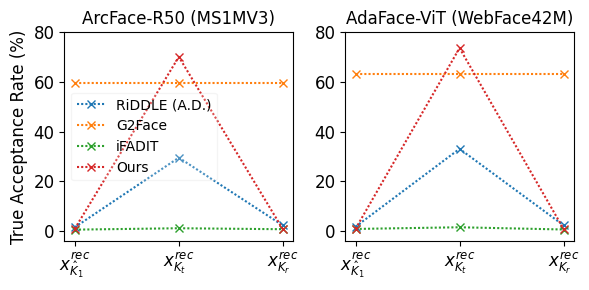

In [15]:
map_models_name = {"facenet_vggface2" : "FaceNet (VGGFace2)", "facenet_casia" : "FaceNet (Casia)",
 "arcface_r50": "ArcFace-R50 (MS1MV3)", "adaface_vit": "AdaFace-ViT (WebFace42M)"}
models = ["facenet_casia", "arcface_r50", "adaface_vit"]
models = ["arcface_r50", "adaface_vit"]
methods = ["RiDDLE", "G2Face", "iFADIT", "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion"]


plt.figure(figsize=(len(models)*3,3))
for i, model in enumerate(models):
    plt.subplot(1, len(models), i+1)
    for method in methods:
        if method !="G2Face":
            tar_wrong_lsb = compute_tar_at_threshold(facef[method][model]["wrong_lsb"].cuda(), clean[model],
            labels1 = names["names1"][:1000],  labels2 = names["names2"], threshold = thresholds[model]) *100
            tar_right_key = compute_tar_at_threshold(facef[method][model]["reconstructed"].cuda(), clean[model],
            labels1 = names["names1"][:1000],  labels2 = names["names2"], threshold = thresholds[model]) *100
            tar_wrong_rand = compute_tar_at_threshold(facef[method][model]["wrong_rand"].cuda(), clean[model],
            labels1 = names["names1"][:1000],  labels2 = names["names2"], threshold = thresholds[model]) *100
        if method == "G2Face":
            tar_g2face = compute_tar_at_threshold(t_g2face[model+"_templates"]["reconstructed"].cuda(), clean[model],
                labels1 = names["names1"][:1000],  labels2 = names["names2"], threshold = thresholds[model]) *100
            tar_wrong_lsb = tar_right_key = tar_wrong_rand = tar_g2face
            method_name = "G2Face"
        elif method == "iFADIT":
            method_name = "iFADIT"
        elif method == "RiDDLE":
            method_name = "RiDDLE (A.D.)"
        else:
            method_name = "Ours"
        # plt.plot(["$K_{true} \oplus \hat K_{1 bit}$", "$K_{true}$", "$K_{random}$"], [tar_wrong_lsb, tar_right_key, tar_wrong_rand], label = method_name, marker = "x", linestyle=(0, (1, 10)))   
        plt.plot(["$x^{rec}_{\hat K_1}$", "$x^{rec}_{K_t}$", "$x^{rec}_{K_r}$"], [tar_wrong_lsb, tar_right_key, tar_wrong_rand], label = method_name, marker = "x", linestyle=(0, (1, 1)))   



    plt.title(map_models_name[model])
    plt.ylim(-4,80)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    if i == 0:
        plt.ylabel("True Acceptance Rate (%)",fontsize=12)
        plt.legend(loc = 'center left', framealpha=0.2)
    if i == len(models)-1:
        pass
plt.tight_layout()
plt.savefig(f"figures/TIFS/cryptanalysis_{DATASET}.png", dpi=500)
plt.show()


# JPEG compression

In [12]:
methods = ["controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion", # unconditionned_mask_anonymized_face_ddim_inversion, controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion
            "G2Face", "iFADIT", "RiDDLE"]
methods = ["controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion"]
# methods = ["RiDDLE", "iFADIT", "unconditionned_mask_anonymized_face_ddim_inversion"]
models = ["facenet_vggface2", "facenet_casia", "arcface_r50", "adaface_vit"]

facef = {method: {model : {} for model in models} for method in methods}
DATASET = "LFW" # "LFW", "CelebA_HQ"

for method in methods:
    if "controlnet" in method:
        results_dir = os.path.join(root, "results", DATASET, "jpeg_compression", "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion")
    elif "iFADIT" in method:
        results_dir = os.path.join(root, "iFADIT", "results", DATASET, "jpeg_compression")
    elif "RiDDLE" in method:
        results_dir = os.path.join(root, "RiDDLE", "results", DATASET, "additional_data", "jpeg_compression")
    elif "unconditionned" in method :
        results_dir = os.path.join(root, "results", DATASET, "jpeg_compression", "unconditionned_mask_anonymized_face_ddim_inversion")
    if method.split("_")[0] in ["controlnet", "unconditionned"]:
        r = torch.load(os.path.join(results_dir, f"results_part_0.pt"))
    elif method in ["iFADIT", "RiDDLE"]:
        r = torch.load(os.path.join(results_dir, f"results.pt"))
    for model in models:
        print(r[model].keys())
        for face_type in r[model].keys():
            facef[method][model][face_type] = r[model][face_type]


dict_keys(['clean', 'anonymized', 'reconstructed', 100, 90, 75, 50])
dict_keys(['clean', 'anonymized', 'reconstructed', 100, 90, 75, 50])
dict_keys(['clean', 'anonymized', 'reconstructed', 100, 90, 75, 50])
dict_keys(['clean', 'anonymized', 'reconstructed', 100, 90, 75, 50])


In [15]:
clean = torch.load(os.path.join(root, "results", "LFW", "clean_first_image.pt"))
for model in clean.keys():
    clean[model] = clean[model
    ]["clean"].cuda()

names = np.load(os.path.join(root, "results", "LFW", "names.npy"), allow_pickle=True)
names = names.item()

In [16]:
thresholds = {model:None for model in clean.keys()}
tar_clean = {model:None for model in clean.keys()}
for model in clean.keys():
    tar_clean[model], thresholds[model] = compute_tar_at_far(t_clean[model + "_templates"].cuda(), clean[model],
    labels1 = names["names1"],  labels2 = names["names2"], target_far=0.001)
print(tar_clean, thresholds)

{'arcface_r50': 0.9905725717544556, 'facenet_vggface2': 0.95146644115448, 'facenet_casia': 0.9095669984817505, 'adaface_vit': 0.9961591958999634} {'arcface_r50': 0.2461916208267212, 'facenet_vggface2': 0.5562377572059631, 'facenet_casia': 0.5122511386871338, 'adaface_vit': 0.24919302761554718}


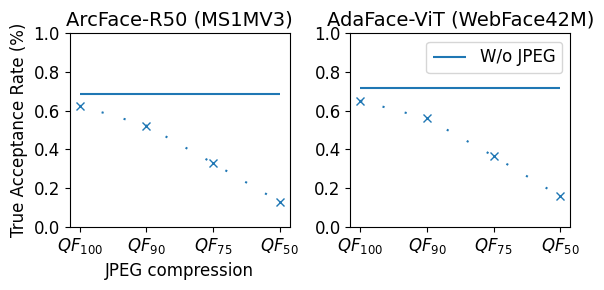

In [35]:
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
map_models_name = {"facenet_vggface2" : "FaceNet (VGGFace2)", "facenet_casia" : "FaceNet (Casia)",
 "arcface_r50": "ArcFace-R50 (MS1MV3)", "adaface_vit": "AdaFace-ViT (WebFace42M)"}
methods = [            "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion"]
models = ["arcface_r50", "adaface_vit"]
xlabels = ["W/o"] + [f"$QF_{{\\text{{{qf}}}}}$" for qf in [100,90,75,50]]
xlabels = [f"$QF_{{\\text{{{qf}}}}}$" for qf in [100,90,75,50]]

plt.figure(figsize=(len(models)*3,3))
plt.clf()
for i, model in enumerate(models):
    plt.subplot(1, len(models), i+1)

    for method in methods:
        tar_reco = []
        Treco = facef[method][model]["reconstructed"].cuda()

        tar_reco_wo = compute_tar_at_threshold(Treco, clean[model],
        labels1 = names["names1"][:1000],  labels2 = names["names2"], threshold = thresholds[model])
        # tar_reco.append(tar_reco_wo)

        for qf in [100,90,75,50]:
            Tqf = facef[method][model][qf].cuda()
            tar_reco.append(compute_tar_at_threshold(Tqf, clean[model],
            labels1 = names["names1"][:1000],  labels2 = names["names2"], threshold = thresholds[model]))

    plt.plot(xlabels, tar_reco, marker="x", linestyle=(0, (1, 10))) # , markersize=12
    plt.hlines(tar_reco_wo, xmin=xlabels[0], xmax= xlabels[-1], label = "W/o JPEG")

        # sns.kdeplot(sim.cpu(), label = method_name, kde=True, stat="probability")

    if model == models[0]:
        plt.ylabel("True Acceptance Rate (%)",fontsize=12)
        plt.xlabel("JPEG compression",fontsize=12)
    else:
        plt.ylabel("")
        plt.xlabel("")
    if model == models[-1]:
        plt.legend(fontsize=12)
    plt.title(map_models_name[model],fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0,1)

# plt.suptitle(DATASET, fontsize=16)
plt.tight_layout()
plt.savefig(f"figures/TIFS/JPEG_quanti_{DATASET}_v2.png", dpi=500)
plt.show()####
